In [1]:
%load_ext autoreload
%autoreload 2

# Part 6: Titanic - Training with MLP
Goal of this notebook is train custom-built Multilayer Perceptron (MLP) on preprocessed Titanic dataset

**Key step:**
* **Load Data:** Import cleaned data from notebook 5
* **Build Network:** Assemble MLP architecture (Dense Layer + Activations)
* **Train and Evaluate:** Train model and monitor validation metrics to prevent Overfitting

## Import libraries

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle

sys.path.append('../')
from core.activation import ReLU,Sigmoid
from core.layer import Dense
from core.loss import bce,bce_prime
from core.network import Network
from core.utils import prob_to_class
from core.metrics import accuracy_score,precision_score,recall_score,f1_score
import copy

## 1. Load dataset 

In [2]:
X_train=np.load('../data/processed/X_train.npy')
y_train=np.load('../data/processed/y_train.npy')
X_val=np.load('../data/processed/X_val.npy')
y_val=np.load('../data/processed/y_val.npy')
X_test=np.load('../data/processed/X_test.npy')
y_test=np.load('../data/processed/y_test.npy')

In [3]:
X_train

array([[-0.81609293,  1.11674917,  0.11068539, ..., -0.30493025,
         0.62996904,  1.48705757],
       [-0.12674551, -0.77697054, -0.55880005, ..., -0.30493025,
         0.62996904, -0.67246892],
       [-0.12674551, -0.79714962, -0.55880005, ...,  3.27943852,
        -1.58737961, -0.67246892],
       ...,
       [ 1.40513767,  0.6668188 ,  2.11914172, ..., -0.30493025,
         0.62996904, -0.67246892],
       [ 1.32854351,  0.78363105, -0.55880005, ..., -0.30493025,
         0.62996904, -0.67246892],
       [-0.81609293,  0.39174174,  0.78017083, ..., -0.30493025,
         0.62996904,  1.48705757]], shape=(623, 9))

In [4]:
y_train.shape

(623, 1)

In [5]:
input_features=X_train.shape[1]
print(f'Number of input features: {input_features}')

Number of input features: 9


## 2. Base Model and Visualizing learning process
* **Input Layer:** Receive matrix from dataset
* **Hidden Layer 1:** Extend features space (16 neurons) combine `ReLU` activation
* **Hidden Layer 2:** Compress features space (8 neurons) combine `ReLU`
* **Output Layer:** Compress to 1 neuron combine `Sigmoid` activation function 

In [6]:
base_model=Network()

base_model.add(Dense(input_size=input_features,output_size=16))
base_model.add(ReLU())

base_model.add(Dense(input_size=16,output_size=8))
base_model.add(ReLU())

base_model.add(Dense(input_size=8,output_size=1))
base_model.add(Sigmoid())

**Use Binary Cross-Entropy for Classification Problem**

In [7]:
base_model.compile(loss=bce,loss_prime=bce_prime)

**Training model**

In [8]:
train_history,val_history=base_model.fit(X_train,y_train,epochs=1500,learning_rate=0.05,verbose=True,
                                         X_val=X_val,y_val=y_val)

Epoch  100/1500 | Train_Loss: 0.673605 | Val_Loss: 0.580355
Epoch  200/1500 | Train_Loss: 0.504008 | Val_Loss: 0.485050
Epoch  300/1500 | Train_Loss: 0.493201 | Val_Loss: 0.472109
Epoch  400/1500 | Train_Loss: 0.483771 | Val_Loss: 0.460409
Epoch  500/1500 | Train_Loss: 0.475194 | Val_Loss: 0.450697
Epoch  600/1500 | Train_Loss: 0.467656 | Val_Loss: 0.443750
Epoch  700/1500 | Train_Loss: 0.459733 | Val_Loss: 0.437402
Epoch  800/1500 | Train_Loss: 0.454062 | Val_Loss: 0.434413
Epoch  900/1500 | Train_Loss: 0.448643 | Val_Loss: 0.432684
Epoch 1000/1500 | Train_Loss: 0.443670 | Val_Loss: 0.430699
Epoch 1100/1500 | Train_Loss: 0.438995 | Val_Loss: 0.428336
Epoch 1200/1500 | Train_Loss: 0.434921 | Val_Loss: 0.425781
Epoch 1300/1500 | Train_Loss: 0.430819 | Val_Loss: 0.422699
Epoch 1400/1500 | Train_Loss: 0.427152 | Val_Loss: 0.420170
Epoch 1500/1500 | Train_Loss: 0.423009 | Val_Loss: 0.416716


**Visualizing Learning Curve**

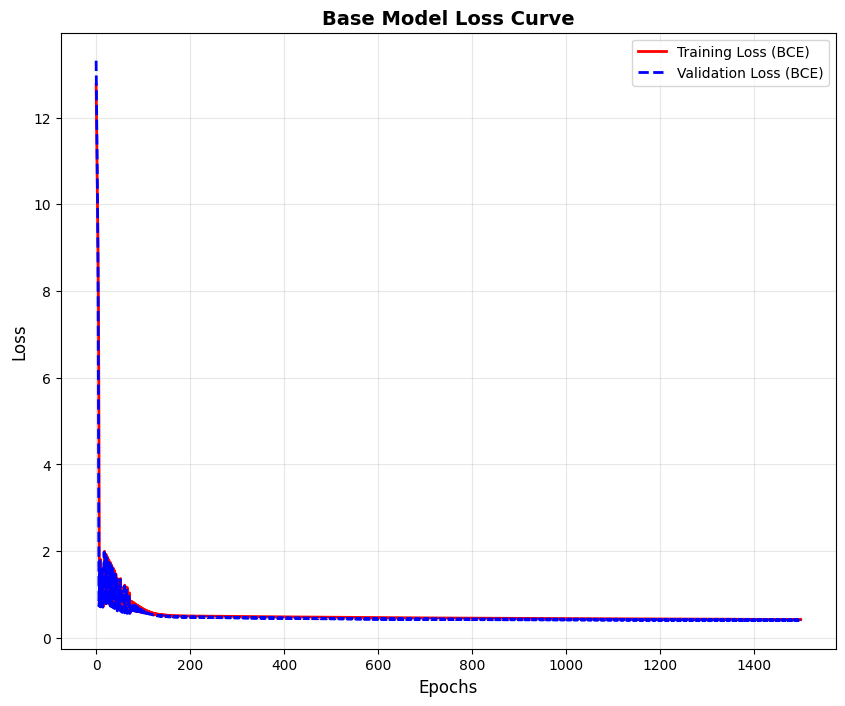

In [9]:
plt.figure(figsize=(10,8))
plt.plot(train_history,label='Training Loss (BCE)',color='r',linewidth=2)
plt.plot(val_history,label='Validation Loss (BCE)',color='b',linewidth=2,linestyle='--')
plt.title('Base Model Loss Curve',fontsize=14,fontweight='bold')
plt.xlabel('Epochs',fontsize=12)
plt.ylabel('Loss',fontsize=12)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

**Base Model Validation Accuracy**

In [10]:
val_predictions_prob=base_model.predict(X_val)
val_predictions_class=prob_to_class(val_predictions_prob)
val_acc=accuracy_score(y_val,val_predictions_class)
print(f'Base Model Validation Accuracy: {val_acc}')

Base Model Validation Accuracy: 0.8208955223880597


## 3. Fine-tunning
We will use search space includes differrent learning rates and epochs to find best model based on **Validation Accuracy**

**Search space:**

In [11]:
learning_rates=[0.1,0.05,0.01]
epochs_list=[500,1000,2000]

**Find best model**

In [12]:
best_params={}
best_model=None
best_accuracy=0
best_train_history=None
best_val_history=None

for learning_rate in learning_rates:
    for epoch in epochs_list:
        model=Network()
        model.add(Dense(input_size=input_features,output_size=16))
        model.add(ReLU())

        model.add(Dense(input_size=16,output_size=8))
        model.add(ReLU())

        model.add(Dense(input_size=8,output_size=1))
        model.add(Sigmoid())
        
        model.compile(bce,bce_prime)
        
        train_history,val_history=model.fit(X_train,y_train,epochs=epoch,learning_rate=learning_rate,
                                            X_val=X_val,y_val=y_val,verbose=False)
        val_predictions_prob=model.predict(X_val)
        val_predictions_class=prob_to_class(val_predictions_prob)
        val_acc=accuracy_score(y_val,val_predictions_class)
        
        print(f'Learning_rate: {learning_rate} | Epoch: {epoch} | Val Accuracy: {val_acc}')
        
        if val_acc>best_accuracy:
            best_accuracy=val_acc
            best_model=copy.deepcopy(model)
            best_params={'learning_rate':learning_rate,'epoch':epoch}
            best_train_history=train_history
            best_val_history=val_history

Learning_rate: 0.1 | Epoch: 500 | Val Accuracy: 0.8283582089552238
Learning_rate: 0.1 | Epoch: 1000 | Val Accuracy: 0.8208955223880597
Learning_rate: 0.1 | Epoch: 2000 | Val Accuracy: 0.7910447761194029
Learning_rate: 0.05 | Epoch: 500 | Val Accuracy: 0.8134328358208955
Learning_rate: 0.05 | Epoch: 1000 | Val Accuracy: 0.8507462686567164
Learning_rate: 0.05 | Epoch: 2000 | Val Accuracy: 0.8208955223880597
Learning_rate: 0.01 | Epoch: 500 | Val Accuracy: 0.8134328358208955
Learning_rate: 0.01 | Epoch: 1000 | Val Accuracy: 0.8283582089552238
Learning_rate: 0.01 | Epoch: 2000 | Val Accuracy: 0.8507462686567164


**Best hyperparameters**

In [13]:
best_params

{'learning_rate': 0.05, 'epoch': 1000}

**Best Accuracy**

In [14]:
print(best_accuracy)

0.8507462686567164


**Visualizing best model learning process**

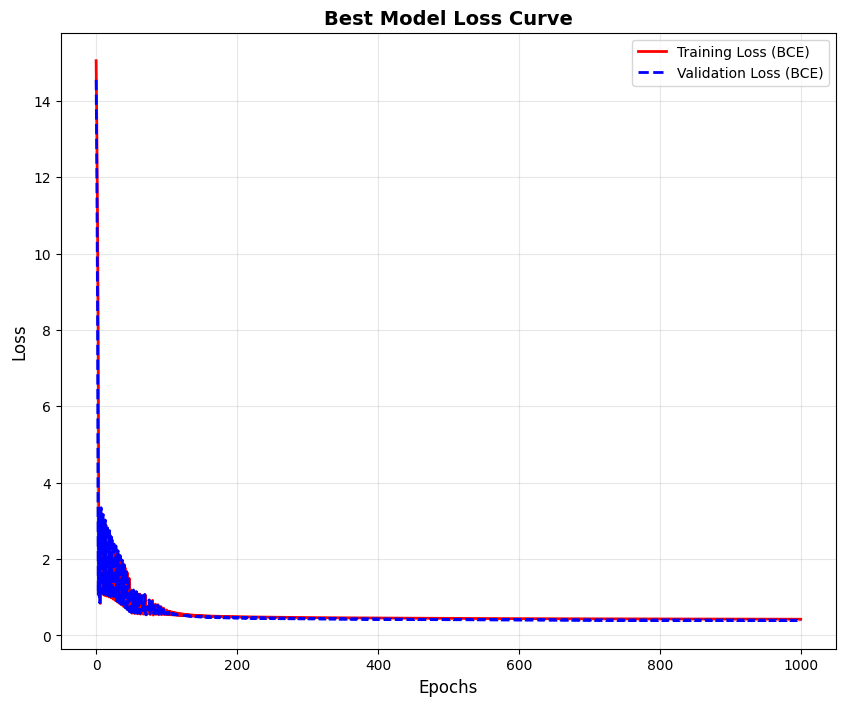

In [15]:
plt.figure(figsize=(10,8))
plt.plot(best_train_history,label='Training Loss (BCE)',color='r',linewidth=2)
plt.plot(best_val_history,label='Validation Loss (BCE)',color='b',linewidth=2,linestyle='--')
plt.title('Best Model Loss Curve',fontsize=14,fontweight='bold')
plt.xlabel('Epochs',fontsize=12)
plt.ylabel('Loss',fontsize=12)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 4. Evaluate best model on test set

### 4.1. Predict on test set

In [16]:
test_predict_prob=best_model.predict(X_test)
test_predict_class=prob_to_class(test_predict_prob)

### 4.2. Evaluate

In [17]:
test_accuracy=accuracy_score(y_test,test_predict_class)
test_precision=precision_score(y_test,test_predict_class)
test_recall=recall_score(y_test,test_predict_class)
test_f1=f1_score(y_test,test_predict_class)
print(f'Accuracy: {test_accuracy}')
print(f'Precision: {test_precision}')
print(f'Recall: {test_recall}')
print(f'F1: {test_f1}')

Accuracy: 0.7985074626865671
Precision: 0.8
Recall: 0.6274509803921569
F1: 0.7032967032967032


## 5. Save best model

In [18]:
with open('../models/titanic_best_model.pkl','wb') as f:
    pickle.dump(best_model,f)